In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import fisher_exact, chi2
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from firthlogist import FirthLogisticRegression
from scipy.stats import norm
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

In [2]:
tcga_path = 'data/tcga_mut_somaticgermline.tsv'
roles_path = "data/generoles.tsv"
wgd_path = 'data/tissue_wgd.tsv'
allhitfreq_path = 'data/allhitfreq_wgdstatus.tsv'
mutcat_path = "data/mutcat_nofilter.tsv"

In [3]:
tcga = pd.read_csv(tcga_path, sep='\t')
roles = pd.read_csv(roles_path, sep='\t')
wgd = pd.read_csv(wgd_path, sep='\t')
allhitfreq = pd.read_csv(allhitfreq_path, sep = '\t')
mutcat = pd.read_csv(mutcat_path, sep='\t')

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig S7B

In [5]:
# preparing dataset

tcgazf = tcga[tcga.midan_filter=='keep']
tcgazf_nosil = tcgazf[tcgazf.Variant_Classification!='Silent']
tcga_nosil = tcga[tcga.Variant_Classification!='Silent']

# calculating pancancer 2 hit frequencies

pancan2hitfreqs = tcgazf_nosil.groupby(['Hugo_Symbol','zygosity'])['tissue'].nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index='Hugo_Symbol',columns='zygosity',values='counts').fillna(0).reset_index()
pancan2hitfreqs['tot'] = pancan2hitfreqs['1-hit']+pancan2hitfreqs['2-hit']
pancan2hitfreqs = pancan2hitfreqs[pancan2hitfreqs.tot>=5]
pancan2hitfreqs['2hitfreq'] = pancan2hitfreqs['2-hit']/pancan2hitfreqs['tot']
pancan2hitfreqs = pd.merge(pancan2hitfreqs,roles, on='Hugo_Symbol', how='left')

# calculating pancancer all hit frequencies 

pancanallhitfreqs = tcga_nosil.groupby(['Hugo_Symbol','zygo_re'])['tissue'].nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index=['Hugo_Symbol'],columns='zygo_re',values='counts').fillna(0).reset_index()
pancanallhitfreqs['tot'] = pancanallhitfreqs['All-hit'] + pancanallhitfreqs['Some-hit']
pancanallhitfreqs = pancanallhitfreqs[pancanallhitfreqs['tot']>=5]
pancanallhitfreqs['allhitfreq'] = pancanallhitfreqs['All-hit']/pancanallhitfreqs['tot']
pancanallhitfreqs = pd.merge(pancanallhitfreqs,roles, on='Hugo_Symbol', how='left')

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


SignificanceResult(statistic=0.8765712229732827, pvalue=0.0)


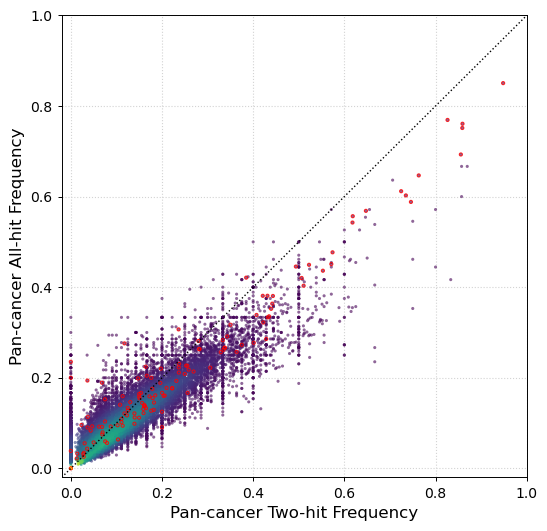

In [6]:
config_rcparams()

data = pd.merge(pancan2hitfreqs,pancanallhitfreqs,on=['Hugo_Symbol','role'])

values = np.vstack([data["2hitfreq"], data["allhitfreq"]])
kernel = stats.gaussian_kde(values)(values)

fig, ax = plt.subplots(figsize=(6, 6))

# Base scatter with KDE coloring
sc = ax.scatter(
    data["2hitfreq"], data["allhitfreq"],
    c=kernel,
    cmap="viridis",
    s=5,         
    alpha=0.6,
    edgecolor="none"
)

ax.plot([-0.1, 1], [-0.1, 1], ":", color='k', linewidth=1)
plt.xlim(-0.02,1)
plt.ylim(-0.02,1)

# Highlight TSG points in red
tsg_data = data[data["role"] == "TSG"]
ax.scatter(
    tsg_data["2hitfreq"], tsg_data["allhitfreq"],
    facecolors="none",     # no fill
    edgecolors="red",
    s=5,          
    alpha = 0.8, linewidths=0.8
)

ax.set_xlabel("Pan-cancer Two-hit Frequency",fontsize=12)
ax.set_ylabel("Pan-cancer All-hit Frequency",fontsize=12)

ax.grid(True,color='lightgrey', linestyle =':')
ax.set_axisbelow(True)  

tmp = data[['2hitfreq','allhitfreq']].dropna()
print(stats.spearmanr(tmp['2hitfreq'].values,tmp['allhitfreq'].values))

plt.show()

---

# Fig S7F

In [7]:
# preparing dataset

# calculating WGD status specific pancancer all hit frequencies 

wgdpanallhitfreqs = tcga_nosil.groupby(['WGD','Hugo_Symbol','zygo_re'])['tissue'].nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index=['WGD','Hugo_Symbol'],columns='zygo_re',values='counts').fillna(0).reset_index()
wgdpanallhitfreqs['tot'] = wgdpanallhitfreqs['All-hit'] + wgdpanallhitfreqs['Some-hit']
print(len(wgdpanallhitfreqs))
wgdpanallhitfreqs = wgdpanallhitfreqs[wgdpanallhitfreqs['tot']>=5]
print(len(wgdpanallhitfreqs))
wgdpanallhitfreqs['allhitfreq'] = wgdpanallhitfreqs['All-hit']/wgdpanallhitfreqs['tot']

print(len(wgdpanallhitfreqs))
wgdpanallhitfreqs = pd.merge(wgdpanallhitfreqs,roles, on='Hugo_Symbol', how='left')
print(len(wgdpanallhitfreqs))

38140
33324
33324
33324


In [8]:
# calculating GD status specific pancancer all hit frequencies 

gdpanallhitfreqs = tcga_nosil.groupby(['Genome_doublings','Hugo_Symbol','zygo_re'])['tissue'].nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index=['Genome_doublings','Hugo_Symbol'],columns='zygo_re',values='counts').fillna(0).reset_index()
gdpanallhitfreqs['tot'] = gdpanallhitfreqs['All-hit'] + gdpanallhitfreqs['Some-hit']
print(len(gdpanallhitfreqs))
gdpanallhitfreqs = gdpanallhitfreqs[gdpanallhitfreqs['tot']>=5]
print(len(gdpanallhitfreqs))
gdpanallhitfreqs['allhitfreq'] = gdpanallhitfreqs['All-hit']/gdpanallhitfreqs['tot']

print(len(gdpanallhitfreqs))
gdpanallhitfreqs = pd.merge(gdpanallhitfreqs,roles, on='Hugo_Symbol', how='left')
print(len(gdpanallhitfreqs))

52691
36025
36025
36025


KstestResult(statistic=0.1111111111111111, pvalue=0.7695469627551301, statistic_location=0.10344827586206896, statistic_sign=-1)
KstestResult(statistic=0.3194444444444444, pvalue=0.0011934863932667047, statistic_location=0.0, statistic_sign=-1)


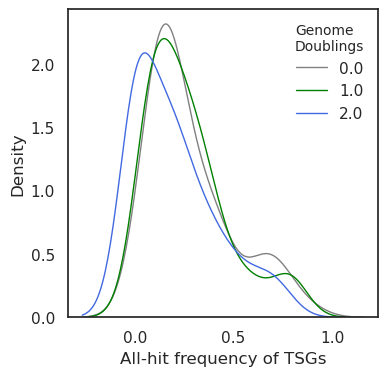

In [9]:
config_rcparams()

sns.set(rc={'figure.figsize':(4,4)})
sns.set_style('white')

tmp = gdpanallhitfreqs[gdpanallhitfreqs.role=='TSG'].pivot(
    index='Hugo_Symbol',
    columns='Genome_doublings',
    values='allhitfreq'
).dropna()

ax = plt.gca()
colors = ['gray','green','royalblue']

for i, col in enumerate(tmp.columns):
    sns.kdeplot(tmp[col].dropna(), color=colors[i], linewidth=1, ax=ax, label=str(col))

ax.legend(title="Genome\nDoublings", title_fontsize=10, frameon=False)
ax.set_xlabel('All-hit frequency of TSGs', fontsize=12)

print(stats.ks_2samp(tmp.iloc[:,0].values, tmp.iloc[:,1].values))
print(stats.ks_2samp(tmp.iloc[:,0].values, tmp.iloc[:,2].values))

plt.show()

---

# Fig 4A

In [10]:
# preparing dataset 

wgdpanallhitfreqs_piv = wgdpanallhitfreqs.pivot(index=['Hugo_Symbol','role'],columns='WGD',values='allhitfreq').reset_index()
tmp = wgdpanallhitfreqs.groupby(['Hugo_Symbol'])['tot'].sum().to_frame().reset_index()
wgdpanallhitfreqs_piv = pd.merge(wgdpanallhitfreqs_piv, tmp, on='Hugo_Symbol', how='left')

tmp = wgdpanallhitfreqs[wgdpanallhitfreqs.WGD=='WGD+'][['Hugo_Symbol','tot']].rename(columns={'tot':'wgdtot'})
wgdpanallhitfreqs_piv = pd.merge(wgdpanallhitfreqs_piv, tmp, on='Hugo_Symbol', how='left')
wgdpanallhitfreqs_piv['wgdbytot'] = wgdpanallhitfreqs_piv['wgdtot']/wgdpanallhitfreqs_piv['tot']

data = wgdpanallhitfreqs_piv[wgdpanallhitfreqs_piv.role=='TSG']

SignificanceResult(statistic=0.7102336592557149, pvalue=3.0163315230694453e-21)


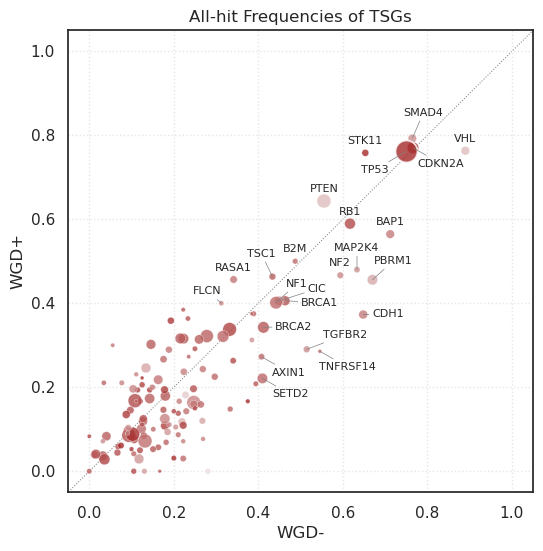

In [11]:
config_rcparams()

sns.set(rc={'figure.figsize':(6,6)})
sns.set_style('white')

genes_to_annotate = {
    "TP53": (-22, -22),
    "SMAD4": (8, 10),
    "CDKN2A": (20, -20),
    "PBRM1": (15,5),
    "MAP2K4": (0,7),
    "TSC1": (-8,8),
    "APC": (-18,5),
    "ATM": (-20,-2),
    "AXIN1": (20, -20),
    "SETD2": (20, -20),
    "TNFRSF14": (20, -20),
    "MEN1": (18,-10),
    "TGFBR2": (28,2),
    "BRCA2": (22,-8),
    "BRCA1": (25,-10),
    "CDH1": (18,-8),
    "AJUBA": (-5,3),
    "CDKN2C": (-35,5),
    "NF1": (15,5),
    "CIC": (27,0),
    "ACVR2A": (20, -20),
    "CASP8": (18,0),
    "GATA3": (20, -25),
    "FANCD2": (15,0),
    "FLCN" : (-10,0)
}


data = wgdpanallhitfreqs_piv[wgdpanallhitfreqs_piv.role=='TSG']

data1 = data[data.tot<=3000]
data2 = data[data.tot>3000]

size_lower = 5
size_upper = np.percentile(data['tot'], 95)   
hue_lower = 0.1
hue_upper = np.percentile(data['wgdbytot'], 95)  

palette = sns.color_palette("light:brown", as_cmap=True)
ax = sns.scatterplot(data=data1,x='WGD-',y='WGD+', size='tot', alpha=0.8, hue='wgdbytot', palette=palette, legend=False,  sizes=(5, 100),     
                     size_norm=(size_lower, size_upper), hue_norm=(hue_lower, hue_upper), zorder=1)
ax = sns.scatterplot(data=data2,x='WGD-',y='WGD+', legend=False, alpha=0.8,  s=250, hue='wgdbytot', palette=palette, hue_norm=(data['wgdbytot'].min(), hue_upper), zorder=1)     

# Add text labels

labelled = data[(data['WGD+']>=0.4)|(data['WGD-']>=0.4)]


for _, row in labelled.iterrows():
    x, y = row['WGD-'], row['WGD+']
    label = row['Hugo_Symbol']
    dx, dy = (0, 5)  
    
    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )

ax.set_xlabel('WGD-',fontsize=12)
ax.set_ylabel('WGD+',fontsize=12)
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1.05)
ax.plot([-0.1, 1.1], [-0.1, 1.1],color='grey',linestyle=':',linewidth=0.75, zorder=0)
ax.grid(True,color='#E6E6E6', linestyle =':')

plt.title('All-hit Frequencies of TSGs')

tmp = data[['WGD+','WGD-']].dropna()
print(stats.spearmanr(tmp['WGD+'].values,tmp['WGD-'].values))

plt.show()

---

# Fig 4B

In [12]:
# preparing dataset for other gene scatterplot

data = pd.merge(pancan2hitfreqs,pancanallhitfreqs,on=['Hugo_Symbol','role'])
others = data[data.role.isin(['other','nonessential'])].copy()

ha = others[others['allhitfreq']>=0.4]['Hugo_Symbol'].unique()
ht = others[others['2hitfreq']>=0.4]['Hugo_Symbol'].unique()

highbothoth = np.intersect1d(ha,ht)
highalloth = np.setdiff1d(ha,highbothoth)
hightwooth = np.setdiff1d(ht,highbothoth)

print(len(highbothoth)+len(highalloth)+len(hightwooth) == len(ha)+len(ht)-len(highbothoth))
print(len(ha)+len(ht)-len(highbothoth))

wgdpanallhitfreqs_piv_oth = wgdpanallhitfreqs_piv.copy()

wgdpanallhitfreqs_piv_oth['group']=''
wgdpanallhitfreqs_piv_oth['group'] = wgdpanallhitfreqs_piv_oth['group'].mask(wgdpanallhitfreqs_piv_oth['Hugo_Symbol'].isin(highbothoth),'hb')
wgdpanallhitfreqs_piv_oth['group'] = wgdpanallhitfreqs_piv_oth['group'].mask(wgdpanallhitfreqs_piv_oth['Hugo_Symbol'].isin(highalloth),'ha')
wgdpanallhitfreqs_piv_oth['group'] = wgdpanallhitfreqs_piv_oth['group'].mask(wgdpanallhitfreqs_piv_oth['Hugo_Symbol'].isin(hightwooth),'ht')
wgdpanallhitfreqs_piv_othhigh = wgdpanallhitfreqs_piv_oth[wgdpanallhitfreqs_piv_oth.group.isin(['ha','hb','ht'])]

highoth = wgdpanallhitfreqs_piv_othhigh.Hugo_Symbol.unique()

print(len(wgdpanallhitfreqs_piv_othhigh))
wgdpanallhitfreqs_piv_othhigh.group.value_counts()

True
240
222


ht    174
hb     42
ha      6
Name: group, dtype: int64

SignificanceResult(statistic=-0.4149705179818067, pvalue=4.42040904539619e-08)


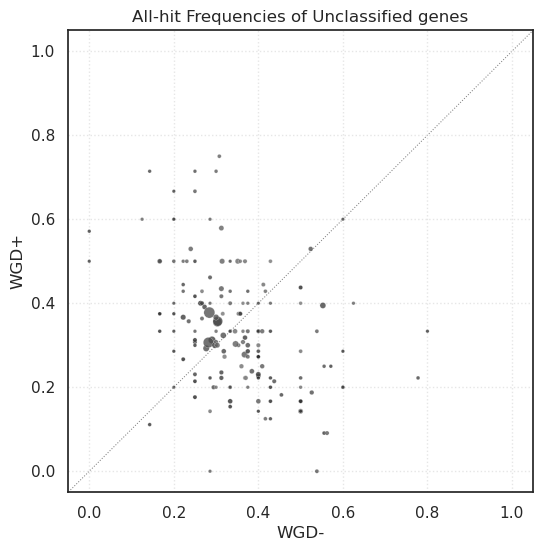

In [13]:
config_rcparams()

sns.set(rc={'figure.figsize':(6,6)})
sns.set_style('white')

data = wgdpanallhitfreqs_piv_othhigh
   
hue_lower = 0.1
hue_upper = np.percentile(data.dropna()['wgdbytot'], 95) 

palette = sns.color_palette("dark:darkgray_r", as_cmap=True)

ax = sns.scatterplot(data=data,x='WGD-',y='WGD+', size='tot',  hue='wgdbytot', alpha=0.8, legend=False, palette=palette, sizes=(5, 100),   
                    size_norm=(size_lower, size_upper), hue_norm=(hue_lower, hue_upper), zorder=1)


ax.set_xlabel('WGD-',fontsize=12)
ax.set_ylabel('WGD+',fontsize=12)
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1.05)
ax.plot([-0.1, 1.1], [-0.1, 1.1],color='grey',linestyle=':',linewidth=0.75, zorder=0)
ax.grid(True,color='#E6E6E6', linestyle =':')

plt.title('All-hit Frequencies of Unclassified genes')

tmp = data[['WGD+','WGD-']].dropna()
print(stats.spearmanr(tmp['WGD+'].values,tmp['WGD-'].values))

plt.show()

---

# Fig S7D

SignificanceResult(statistic=0.3088514069195579, pvalue=1.6087301261617282e-254)


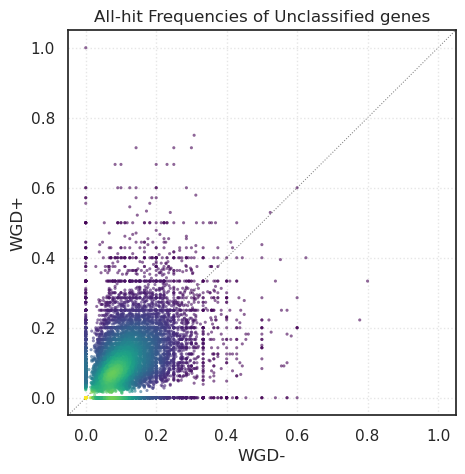

In [14]:
config_rcparams()

sns.set(rc={'figure.figsize':(6,6)})
sns.set_style('white')

data = wgdpanallhitfreqs_piv[wgdpanallhitfreqs_piv.role.isin(['other','nonessential'])][['WGD+','WGD-']].dropna()

values = np.vstack([data["WGD-"], data["WGD+"]])
kernel = stats.gaussian_kde(values)(values)

fig, ax = plt.subplots(figsize=(5,5))

# Base scatter with KDE coloring
sc = ax.scatter(
    data["WGD-"], data["WGD+"],
    c=kernel,
    cmap="viridis",
    s=5,           
    alpha=0.6,
    edgecolor="none"
)

ax.set_xlabel('WGD-',fontsize=12)
ax.set_ylabel('WGD+',fontsize=12)
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1.05)
ax.plot([-0.1, 1.1], [-0.1, 1.1],color='grey',linestyle=':',linewidth=0.75, zorder=0)
ax.grid(True,color='#E6E6E6', linestyle =':')

plt.title('All-hit Frequencies of Unclassified genes')

tmp = data[['WGD+','WGD-']].dropna()
print(stats.spearmanr(tmp['WGD+'].values,tmp['WGD-'].values))

plt.show()

---

# Fig S7C

In [15]:
# preparing dataset

# calculating WGD status specific pancancer all hit frequencies 

wgdtumallhitfreqs = tcga_nosil.groupby(['WGD','Hugo_Symbol','CODE','zygo_re'])['tissue'].nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index=['WGD','Hugo_Symbol','CODE'],columns='zygo_re',values='counts').fillna(0).reset_index()
wgdtumallhitfreqs['tot'] = wgdtumallhitfreqs['All-hit'] + wgdtumallhitfreqs['Some-hit']
print(len(wgdtumallhitfreqs))
wgdtumallhitfreqs = wgdtumallhitfreqs[wgdtumallhitfreqs['tot']>=5]
print(len(wgdtumallhitfreqs))
wgdtumallhitfreqs['allhitfreq'] = wgdtumallhitfreqs['All-hit']/wgdtumallhitfreqs['tot']

print(len(wgdtumallhitfreqs))
wgdtumallhitfreqs = pd.merge(wgdtumallhitfreqs,roles, on='Hugo_Symbol', how='left')
print(len(wgdtumallhitfreqs))

354713
37776
37776
37776


In [16]:
# continued...

wgdtumallhitfreqs_piv = wgdtumallhitfreqs.pivot(index=['Hugo_Symbol','role','CODE'], columns='WGD', values='allhitfreq').dropna()
tmp = wgdtumallhitfreqs[wgdtumallhitfreqs.WGD=='WGD+'].set_index(['Hugo_Symbol','role','CODE'])[['tot']].rename(columns={'tot':'wgdtot'})
wgdtumallhitfreqs_piv = wgdtumallhitfreqs_piv.join(tmp).reset_index()
wgdtumallhitfreqs_piv['WGD+ - WGD-'] = wgdtumallhitfreqs_piv['WGD+']- wgdtumallhitfreqs_piv['WGD-']
tmp = wgdtumallhitfreqs.groupby(['Hugo_Symbol','CODE'])['tot'].sum().to_frame().reset_index()
wgdtumallhitfreqs_piv = pd.merge(wgdtumallhitfreqs_piv, tmp, on=['Hugo_Symbol','CODE'], how='left')
wgdtumallhitfreqs_piv['wgdbytot'] = wgdtumallhitfreqs_piv['wgdtot']/wgdtumallhitfreqs_piv['tot']
wgdtumallhitfreqs_piv_tsgs = wgdtumallhitfreqs_piv[wgdtumallhitfreqs_piv.role=='TSG']
tumor = wgdtumallhitfreqs_piv_tsgs[['Hugo_Symbol','CODE','WGD+ - WGD-','wgdbytot','tot']]

wgdpanallhitfreqs_piv['WGD+ - WGD-'] = wgdpanallhitfreqs_piv['WGD+']- wgdpanallhitfreqs_piv['WGD-']
wgdpanallhitfreqs_piv_tsgs = wgdpanallhitfreqs_piv[wgdpanallhitfreqs_piv.role=='TSG']
pan = wgdpanallhitfreqs_piv_tsgs[['Hugo_Symbol','WGD+ - WGD-','wgdbytot','tot']]
pan['CODE'] = 'Pancancer'
pan = pan[['Hugo_Symbol','CODE','WGD+ - WGD-','wgdbytot','tot']]

/tmp/ipykernel_6184/263969199.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pan['CODE'] = 'Pancancer'


/tmp/ipykernel_6184/3274559235.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(code_order, rotation=90, fontsize=9)
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


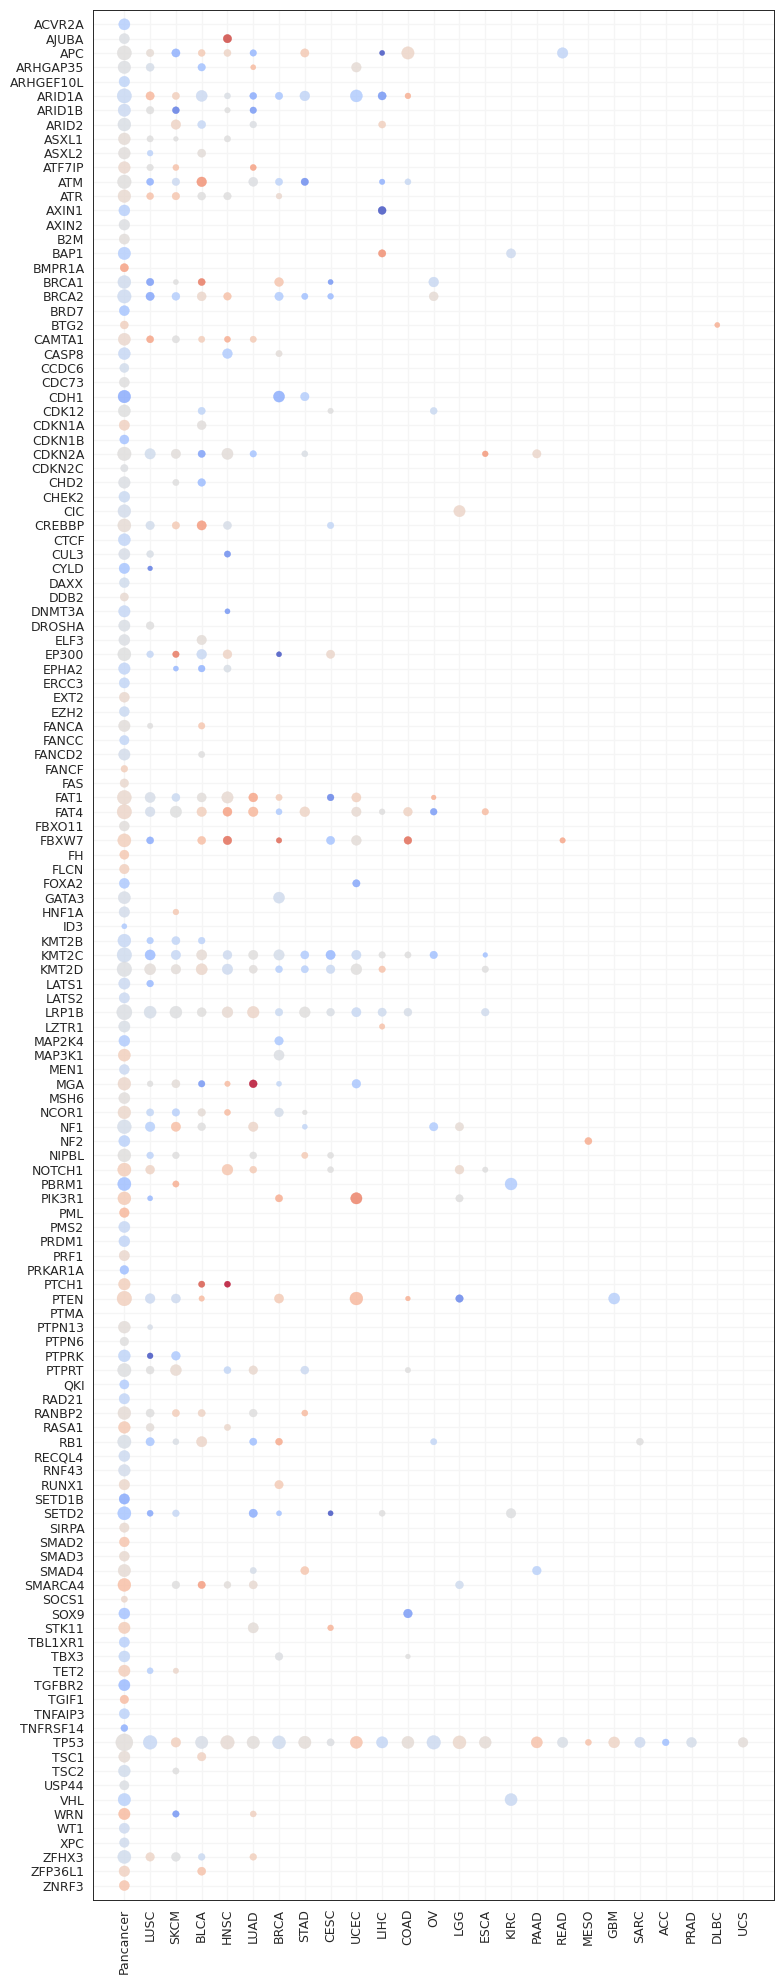

In [17]:
config_rcparams()

df = pd.concat([pan,tumor]).rename(columns={'WGD+ - WGD-': 'WGDdiff'})

code_order = (
    df.dropna(subset=["WGDdiff"])
      .groupby("CODE")["Hugo_Symbol"]
      .count()
      .sort_values(ascending=False)
      .index.tolist()
)

if "Pancancer" in code_order:
    code_order = ["Pancancer"] + [c for c in code_order if c != "Pancancer"]
df["CODE"] = pd.Categorical(df["CODE"], categories=code_order, ordered=True)
df["size_scaled"] = np.log10(df["tot"] + 1)   # +1 to avoid log(0)


plt.figure(figsize=(8, 20))
ax = sns.scatterplot(
    data=df,
    x="CODE",
    y="Hugo_Symbol",
    size="size_scaled",
    #sizes=(2, 200), 
    sizes=(0.5, 150),            
    hue="WGDdiff",
    palette="coolwarm",
    hue_norm=(-0.5, 0.5),
    edgecolor=None,
    linewidth=0.3,
    alpha=0.8,
    legend=False
)

ax.set_xticklabels(code_order, rotation=90, fontsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.grid(True,color='whitesmoke')

plt.ylim(131,-1)
plt.tight_layout()
plt.show()

---

# Fig 4D

In [18]:
# preparing dataset

tcganosil = tcga[tcga.Variant_Classification!='Silent']
tcgans_gd1 = tcganosil[tcganosil['Genome_doublings']==1]
tcgans_gd1_tsgs = tcgans_gd1[tcgans_gd1.Hugo_Symbol.isin(roles[roles.role=='TSG'].Hugo_Symbol.unique())].copy()
tcgans_gd1_tsgs['mut:WT'] = tcgans_gd1_tsgs['nchr'].astype(str) + ':' +tcgans_gd1_tsgs['localCN-nchr'].astype(int).astype(str)
print(len(tcgans_gd1_tsgs))

# prioritisation
t = tcgans_gd1_tsgs.groupby(['Hugo_Symbol','tissue'])['nchr'].nunique()
print(len(t[t>1])) # this many gene-patients have multiple variants with different multiplicities
    # prioritise those variants with highest multiplicity for these cases (so that each gene patient is counted only once)
tcgans_gd1_tsgs = tcgans_gd1_tsgs.loc[
    tcgans_gd1_tsgs.groupby(['Hugo_Symbol', 'tissue'])['nchr'].idxmax()
].reset_index(drop=True)  
    # checking:
t = tcgans_gd1_tsgs.groupby(['Hugo_Symbol','tissue'])['nchr'].nunique()
print(len(t[t>1])) # done
print(len(tcgans_gd1_tsgs))

8837
289
0
8052


/tmp/ipykernel_6184/3575601469.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ylabels, rotation=90, fontsize=14)


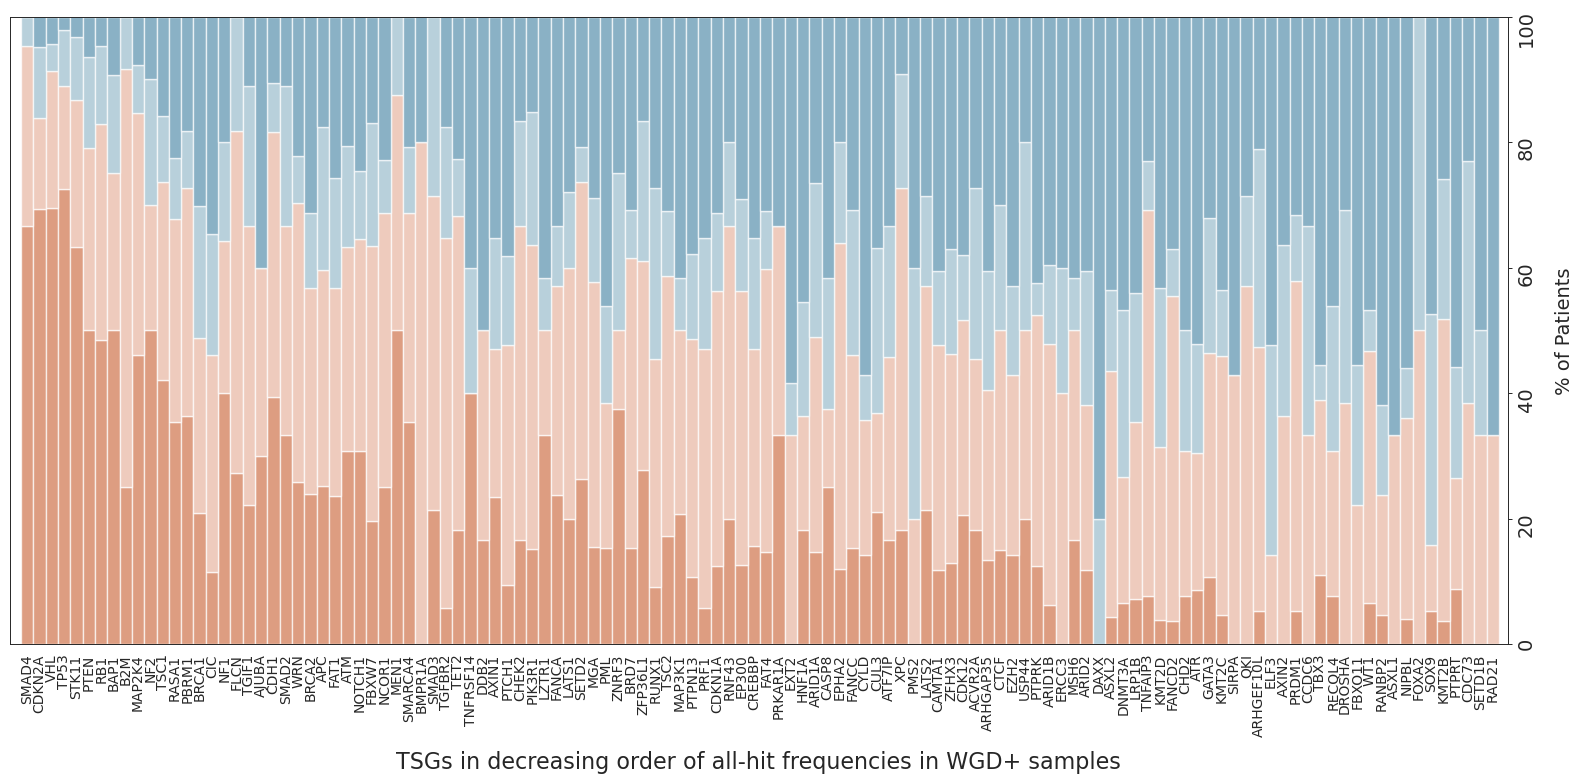

In [20]:
config_rcparams()

# tsgs pancan

# preparing data

tmp_tsgs = tcgans_gd1_tsgs[tcgans_gd1_tsgs['mut:WT'].isin(['1:2','1:1','2:1','2:0'])]
tmp_tsgs = tmp_tsgs.groupby(['Hugo_Symbol','mut:WT'])['tissue'].nunique().to_frame().reset_index().pivot(index='Hugo_Symbol',columns='mut:WT',values='tissue').fillna(0).reset_index()

tmp_tsgs['tot'] = tmp_tsgs['1:2']+tmp_tsgs['1:1']+tmp_tsgs['2:1']++tmp_tsgs['2:0']
tmp_tsgs['P(1:2)'] = tmp_tsgs['1:2']/tmp_tsgs['tot'] 
tmp_tsgs['P(1:1)'] = tmp_tsgs['1:1']/tmp_tsgs['tot'] 
tmp_tsgs['P(2:1)'] = tmp_tsgs['2:1']/tmp_tsgs['tot'] 
tmp_tsgs['P(2:0)'] = tmp_tsgs['2:0']/tmp_tsgs['tot'] 
tmp_tsgs = tmp_tsgs[tmp_tsgs.tot>=5]

order = allhitfreq[(allhitfreq.role=='TSG')&(allhitfreq.WGD=='WGD+')].sort_values(by = 'allhitfreq',ascending=False)[['Hugo_Symbol']].set_index('Hugo_Symbol')
data = order.join(tmp_tsgs.set_index('Hugo_Symbol')[['P(1:2)','P(1:1)','P(2:1)','P(2:0)']]).dropna()

# plotting

fig = plt.figure()
fig.set_size_inches(16,8)

x = data.index
y1 = data['P(2:0)']
y2 = data['P(1:1)']
y3 = data['P(2:1)']
y4 = data['P(1:2)']

plt.bar(x, y1, color='#CF744C', alpha=0.7, width=1) # red
plt.bar(x, y2, bottom=y1, color='#E8B5A2', alpha=0.7, width=1) # light red
plt.bar(x, y3, bottom=y1+y2, color='#9BBDCC', alpha=0.7, width=1) # light blue
plt.bar(x, y4, bottom=y1+y2+y3, color='#5890AD', alpha=0.7, width=1) # blue


# Formatting
plt.ylabel("% of Patients",fontsize=14, labelpad=14)
plt.xticks(range(len(data)), data.index, rotation=90, fontsize=9)
plt.xlabel("TSGs in decreasing order of all-hit frequencies in WGD+ samples", fontsize=16, labelpad=10)

ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.yticks(rotation=90, fontsize=14)
plt.xticks(fontsize=10)

#plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
ylabels = [int(y * 100) for y in ax.get_yticks()]
ax.set_yticklabels(ylabels, rotation=90, fontsize=14)


plt.grid(False)
plt.xlim(-1.4,120.2)
plt.tight_layout()

plt.show()

---

# Fig S8F

In [21]:
# preparing dataset

tcga_nosil['stage_group'] = np.nan
tcga_nosil['stage_group'] = tcga_nosil['stage_group'].mask(tcga_nosil['stage'].isin([1,2]),'low')
tcga_nosil['stage_group'] = tcga_nosil['stage_group'].mask(tcga_nosil['stage'].isin([3,4]),'high')

stagepanallhitfreqs = tcga_nosil.groupby(['stage_group','Hugo_Symbol','zygo_re'])['tissue'].nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index=['stage_group','Hugo_Symbol'],columns='zygo_re',values='counts').fillna(0).reset_index()
stagepanallhitfreqs['tot'] = stagepanallhitfreqs['All-hit'] + stagepanallhitfreqs['Some-hit']
print(len(stagepanallhitfreqs))
stagepanallhitfreqs = stagepanallhitfreqs[stagepanallhitfreqs['tot']>=5]
print(len(stagepanallhitfreqs))
stagepanallhitfreqs['allhitfreq'] = stagepanallhitfreqs['All-hit']/stagepanallhitfreqs['tot']

print(len(stagepanallhitfreqs))
stagepanallhitfreqs = pd.merge(stagepanallhitfreqs,roles, on='Hugo_Symbol', how='left')
print(len(stagepanallhitfreqs))

stagepanallhitfreqs_piv = stagepanallhitfreqs.pivot(index=['Hugo_Symbol','role'],columns='stage_group',values='allhitfreq').reset_index()
tmp = stagepanallhitfreqs.groupby(['Hugo_Symbol'])['tot'].sum().to_frame().reset_index()
stagepanallhitfreqs_piv = pd.merge(stagepanallhitfreqs_piv, tmp, on='Hugo_Symbol', how='left')

tmp = stagepanallhitfreqs[stagepanallhitfreqs.stage_group=='high'][['Hugo_Symbol','tot']].rename(columns={'tot':'hightot'})
stagepanallhitfreqs_piv = pd.merge(stagepanallhitfreqs_piv, tmp, on='Hugo_Symbol', how='left')
stagepanallhitfreqs_piv['highbytot'] = stagepanallhitfreqs_piv['hightot']/stagepanallhitfreqs_piv['tot']

/tmp/ipykernel_6184/2257400794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcga_nosil['stage_group'] = np.nan
/tmp/ipykernel_6184/2257400794.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcga_nosil['stage_group'] = tcga_nosil['stage_group'].mask(tcga_nosil['stage'].isin([1,2]),'low')
/tmp/ipykernel_6184/2257400794.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

37512
30213
30213
30213


SignificanceResult(statistic=0.7465747805517853, pvalue=1.0786467439000544e-23)


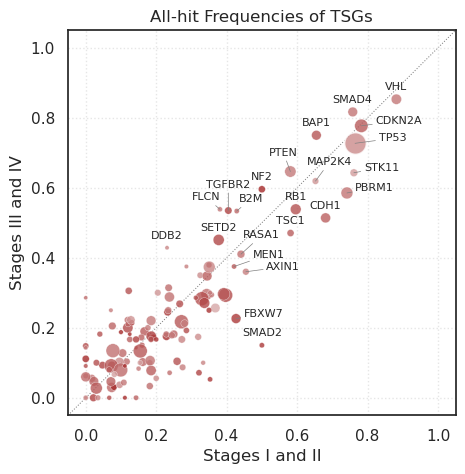

In [22]:
config_rcparams()

sns.set(rc={'figure.figsize':(5,5)})
sns.set_style('white')

genes_to_annotate = {
    "CDKN2A": (27, -5),
    "TP53": (27, -5),
    "PTEN": (-5, 5),
    "AXIN1": (27, -5),
    "MEN1": (25, 0),
    "FLCN": (-10, 0),
    "TGFBR2": (0, 10),
    "B2M":(10,0),
    "PBRM1":(20,-5),
    "STK11":(20,-5),
    "RASA1":(15,5),
    "FBXW7":(20,-5),
    "MAP2K4":(10,5),
}


data = stagepanallhitfreqs_piv[stagepanallhitfreqs_piv.role=='TSG'].dropna()

data1 = data[data.tot<=2000]
data2 = data[data.tot>2000]

size_lower = 5
size_upper = np.percentile(data['tot'], 95)   
hue_lower = 0.1
hue_upper = np.percentile(data['highbytot'], 95)  

palette = sns.color_palette("light:brown", as_cmap=True)
ax = sns.scatterplot(data=data1,x='low',y='high', size='tot', alpha=0.8, hue='highbytot', palette=palette, legend=False,  sizes=(5, 100),     
                     size_norm=(size_lower, size_upper), hue_norm=(hue_lower, hue_upper), zorder=1)
ax = sns.scatterplot(data=data2,x='low',y='high', legend=False, alpha=0.8,  s=250, hue='highbytot', palette=palette, hue_norm=(data['highbytot'].min(), hue_upper), zorder=1)     

# Add text labels

labelled = data[(data['high']>=0.4)|(data['low']>=0.4)]


for _, row in labelled.iterrows():
    x, y = row['low'], row['high']
    label = row['Hugo_Symbol']
    dx, dy = (0, 5)  
    
    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )


ax.set_xlabel('Stages I and II',fontsize=12)
ax.set_ylabel('Stages III and IV',fontsize=12)
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1.05)
ax.plot([-0.1, 1.1], [-0.1, 1.1],color='grey',linestyle=':',linewidth=0.75, zorder=0)
ax.grid(True,color='#E6E6E6', linestyle =':')

plt.title('All-hit Frequencies of TSGs')

tmp = data[['high','low']].dropna()
print(stats.spearmanr(tmp['high'].values,tmp['low'].values))

plt.show()

# Fig S8G

SignificanceResult(statistic=-0.2953320416721895, pvalue=0.0011674579718758122)


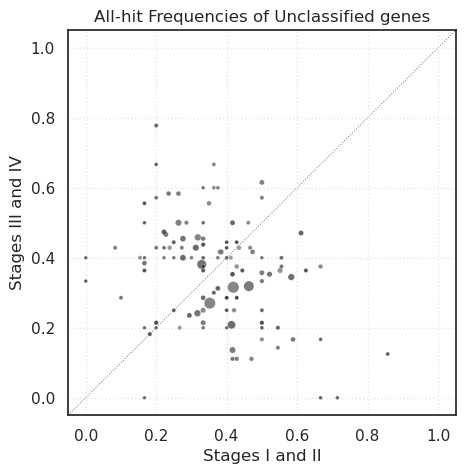

In [23]:
config_rcparams()

sns.set(rc={'figure.figsize':(5,5)})
sns.set_style('white')

data = stagepanallhitfreqs_piv[stagepanallhitfreqs_piv.Hugo_Symbol.isin(highoth)]
   
hue_lower = 0.1
hue_upper = np.percentile(data.dropna()['highbytot'], 95) 

palette = sns.color_palette("dark:darkgray_r", as_cmap=True)

ax = sns.scatterplot(data=data,x='low',y='high', size='tot',  hue='highbytot', alpha=0.8, legend=False, palette=palette, sizes=(5, 100),   
                    size_norm=(size_lower, size_upper), hue_norm=(hue_lower, hue_upper), zorder=1)


ax.set_xlabel('Stages I and II',fontsize=12)
ax.set_ylabel('Stages III and IV',fontsize=12)
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1.05)
ax.plot([-0.1, 1.1], [-0.1, 1.1],color='grey',linestyle=':',linewidth=0.75, zorder=0)
ax.grid(True,color='#E6E6E6', linestyle =':')

plt.title('All-hit Frequencies of Unclassified genes')

tmp = data[['high','low']].dropna()
print(stats.spearmanr(tmp['high'].values,tmp['low'].values))
plt.show()

---

# Fig S7E

In [24]:
# preparng dataset

wgd_mod = wgd[['tissue','Genome_doublings']].copy()
wgd_mod['WGD'] = 'WGD-'
wgd_mod['WGD'] = wgd_mod['WGD'].mask(wgd_mod['Genome_doublings']>0,'WGD+')
wgd_mod['tissue'] = wgd_mod['tissue'].apply(lambda x:x[0:12])
wgd_mod = wgd_mod[['tissue','WGD']].drop_duplicates()

mutcat['tissue'] = mutcat['gene_patient'].apply(lambda x:x.split('_')[1])

print(len(mutcat))
mutcat = pd.merge(mutcat,wgd_mod,on='tissue',how='left')
print(len(mutcat))

1159522
1159522


In [26]:
# continued...

tmp = tcga[['gene_patient','zygo_re']].drop_duplicates()
tmp_dup = tmp[tmp.duplicated(subset='gene_patient',keep=False)==True].copy()
tmp_dup['zygo_re'] = 'All-hit' # prioritising all over some hit in duplicates
tmp_dup = tmp_dup.drop_duplicates()
tmp_nodup = tmp[tmp.duplicated(subset='gene_patient',keep=False)==False].copy()
tmp = pd.concat([tmp_nodup,tmp_dup])
print(len(tmp[tmp.duplicated(subset='gene_patient',keep=False)==True]))

print(len(mutcat))
mutcat = pd.merge(mutcat, tmp,on='gene_patient',how='left')
print(len(mutcat))

# taking tsgs
tsgs = roles[roles.role=='TSG']['Hugo_Symbol'].unique()
mutcat_tsg = mutcat[mutcat.Hugo_Symbol.isin(tsgs)]

0
1159522
1159522


In [27]:
# continued...

df_zygo = mutcat_tsg.groupby(['Hugo_Symbol','WGD','Mutation_Category_genepatient'])['zygo_re'].value_counts().to_frame().unstack().rename({'zygo_re':'count'}, axis='columns')
df_zygo.columns = ['_'.join(col).strip() for col in df_zygo.columns.values]
df_zygo = df_zygo.fillna(0).reset_index()
df_zygo['count_total'] = df_zygo['count_All-hit'] + df_zygo['count_Some-hit']
print(len(df_zygo))
df_zygo = df_zygo[df_zygo['count_total']>=5]
print(len(df_zygo))
df_zygo['allhitfreq'] = df_zygo['count_All-hit']/df_zygo['count_total']

911
688


In [28]:
# continued...

df_zygopivot = df_zygo.pivot(index=['Hugo_Symbol','WGD'],columns=['Mutation_Category_genepatient'],values='allhitfreq').reset_index()
print(len(df_zygopivot))
df_zygopivot = df_zygopivot[['Hugo_Symbol','WGD','lof','mis','sil']]#.dropna()
print(len(df_zygopivot))

256
256


In [29]:
# test

tmpdata = df_zygopivot.dropna().melt(id_vars=['Hugo_Symbol','WGD'],value_vars=['lof','mis','sil'], value_name='allhitfreq')

wgdlof = tmpdata[(tmpdata.WGD=='WGD+')&(tmpdata.Mutation_Category_genepatient=='lof')]['allhitfreq'].values
wgdmis = tmpdata[(tmpdata.WGD=='WGD+')&(tmpdata.Mutation_Category_genepatient=='mis')]['allhitfreq'].values
wgdsil = tmpdata[(tmpdata.WGD=='WGD+')&(tmpdata.Mutation_Category_genepatient=='sil')]['allhitfreq'].values

nowgdlof = tmpdata[(tmpdata.WGD=='WGD-')&(tmpdata.Mutation_Category_genepatient=='lof')]['allhitfreq'].values
nowgdmis = tmpdata[(tmpdata.WGD=='WGD-')&(tmpdata.Mutation_Category_genepatient=='mis')]['allhitfreq'].values
nowgdsil = tmpdata[(tmpdata.WGD=='WGD-')&(tmpdata.Mutation_Category_genepatient=='sil')]['allhitfreq'].values

wgdlofmis = stats.wilcoxon(wgdlof,wgdmis)[1]
wgdmissil = stats.wilcoxon(wgdmis,wgdsil)[1]
wgdlofsil = stats.wilcoxon(wgdlof,wgdsil)[1]

print(wgdlofmis)
print(wgdmissil)
print(wgdlofsil)

nowgdlofmis = stats.wilcoxon(nowgdlof,nowgdmis)[1]
nowgdmissil = stats.wilcoxon(nowgdmis,nowgdsil)[1]
nowgdlofsil = stats.wilcoxon(nowgdlof,nowgdsil)[1]

print(nowgdlofmis)
print(nowgdmissil)
print(nowgdlofsil)

pvals = [wgdlofmis,wgdmissil,wgdlofsil,nowgdlofmis,nowgdmissil,nowgdlofsil]

1.804253221911019e-06
0.04501870939514515
5.4309201805016574e-08
9.907175475149794e-10
0.02605618613014107
6.270570689700617e-09


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


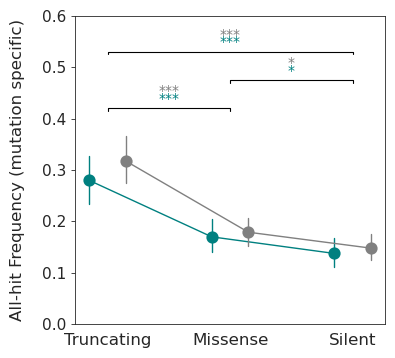

In [30]:
config_rcparams()

fig, ax = plt.subplots(figsize=(4,4))

palette = {'WGD+':'teal','WGD-':'grey'}
mutcat_order = ["lof", "mis", "sil"]

ax = sns.pointplot(
    data=tmpdata,
    x="Mutation_Category_genepatient", y="allhitfreq", hue="WGD",
    order=mutcat_order, stat="median",
    errorbar=("sd"),   
    join=True,
    dodge=0.3, markers="o", palette=palette
)

for line in ax.lines:
    line.set_linewidth(1)

plt.ylabel('All-hit Frequency (mutation specific)', labelpad=12)
plt.xlabel(None)

ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.spines['right'].set_linewidth(0.6)
ax.spines['top'].set_linewidth(0.6)

if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.yaxis.set_ticks_position('left')
ax.tick_params(axis='y', which='both', left=True, right=False, width=0.6, length=3)

ax.set_xticklabels(['Truncating','Missense','Silent'], fontsize=12)
plt.ylim(0,0.6)


pairs = [(0,1), (1,2), (0,2)]  # lof vs mis, mis vs sil, lof vs sil
pvals_WGDP = pvals[:3]
pvals_WGDM = pvals[3:]

colors = {'WGD+':'teal', 'WGD-':'gray'}

def pval_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

y_max = ax.get_ylim()[1]
bracket_gap = 0.055  

for i, (i1, i2) in enumerate(pairs):
    y_bracket = 0.42 + i*bracket_gap 
    x1 = i1
    x2 = i2

    ax.plot([x1, x1, x2, x2], [y_bracket-0.005, y_bracket, y_bracket, y_bracket-0.005],
            lw=0.8, c='black')

    ax.text((x1+x2)/2, y_bracket+0.005, pval_to_star(pvals_WGDP[i]),
            ha='center', va='bottom', color=colors['WGD+'], fontsize=10)
    ax.text((x1+x2)/2, y_bracket+0.02, pval_to_star(pvals_WGDM[i]),
            ha='center', va='bottom', color=colors['WGD-'], fontsize=10)

plt.show()

---